In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [30]:
data = pd.read_csv("../data/wbes_sintetico.csv")

cols = [
    "sales_annual_usd",
    "employees",
    "training",
    "access_finance",
    "exporter",
    "competition_level",
]

df = data[cols].dropna().copy()

In [31]:
mean_sales = df["sales_annual_usd"].mean()
df["successful"] = (df["sales_annual_usd"] > mean_sales).astype(int)

map_comp = {"Baja": 0, "Media": 1, "Alta": 2}
df["competition_level"] = df["competition_level"].map(map_comp)

for c in ["training", "access_finance", "exporter", "competition_level", "successful"]:
    df[c] = df[c].astype(int)

df.shape

(1068, 7)

In [32]:
prob_success = (
    df.groupby(["access_finance", "training"])["successful"]
      .mean()
      .reset_index()
)

prob_success["Etiqueta"] = (
    "Fin: " + prob_success["access_finance"].astype(str) +
    " | Train: " + prob_success["training"].astype(str)
)

prob_success

,access_finance,training,successful,Etiqueta
0,0,0,0.274272,Fin: 0 | Train: 0
1,0,1,0.407942,Fin: 0 | Train: 1
2,1,0,0.439614,Fin: 1 | Train: 0
3,1,1,0.616279,Fin: 1 | Train: 1


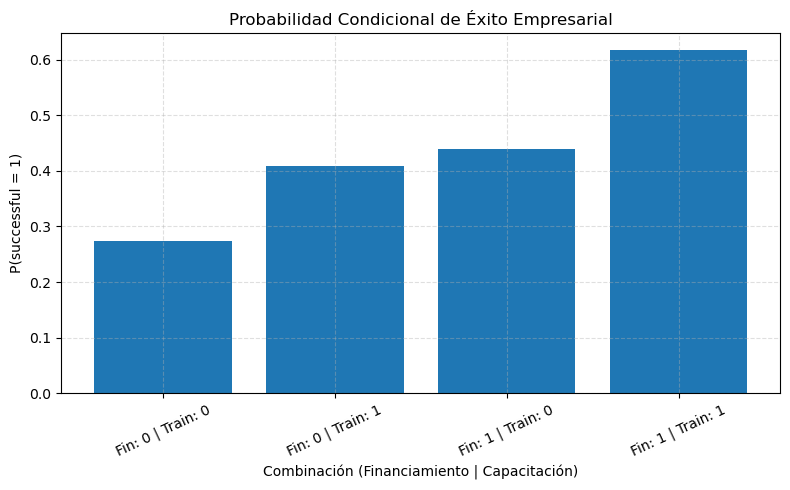

In [33]:
plt.figure(figsize=(8,5))
plt.bar(prob_success["Etiqueta"], prob_success["successful"])
plt.ylabel("P(successful = 1)")
plt.xlabel("Combinación (Financiamiento | Capacitación)")
plt.title("Probabilidad Condicional de Éxito Empresarial")
plt.xticks(rotation=25)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# Analisis de los Resultados

Con base en la información obtenida, se observa que tanto el financiamiento como la capacitación se asocian con mayor éxito empresarial. Cuando no hay ninguno, la probabilidad de éxito es la más baja (0.27), lo que sugiere que la falta de recursos y de habilidades limita el desempeño.

Cuando se agrega solo uno de los factores, la probabilidad sube: con solo capacitación aumenta a 0.41 y con solo financiamiento a 0.44. El mejor escenario es tener ambos, donde la probabilidad llega a 0.62, indicando un efecto combinado que impulsa más el éxito que cada factor por separado.

# Conclsion

Para un responsable de políticas públicas, el modelo más útil es la regresión logística, porque permite clasificar y predecir el éxito empresarial con una medida clara de desempeño y además muestra qué características influyen más en la probabilidad de éxito, lo que ayuda a priorizar intervenciones; la parte bayesiana es valiosa como complemento para interpretar escenarios, pero la logística resulta más directa y operativa para tomar decisiones y justificar políticas.